<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Introduction to Machine Learning and Clustering <a class="tocSkip">

In this session we provide a short introduction to **Machine Learning**, and one of its applications, i.e. **Clustering**. <br>
The goals are:

- to get a grasp of what **machine learning** is 
- to show the basic concept of **data exploration** and **interpretation**
- to **use** clustering algorithms in a particular problem.


# Setup

In [1]:
from collections import defaultdict
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

import warnings
warnings.filterwarnings(action='ignore')

# some handy functions
def add_plot_info():
    """Just add some information for the plot"""
    plt.title('Clusters')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)


Running locally, skipping Colab setup.
Imported matplotlib.
Imported seaborn.
Plotting style set.


# A bit of introduction to ML


![dive_to_python_ml.jpg](images/dive_to_python_ml.jpg)

<table><tr><td width=700><center><br>
    Figure 1. Dive into Python and machine learning! (Source: <a href="https://www.pinterest.ca/pin/549861435766162430/"
 target="_blank" rel="noopener noreferrer"> pinterest random image</a>)
<br></center></td></tr></table>
    

## What is machine learning ?

Arthur Samuel (1959): 

>*"Field of study that gives computers the ability to learn without being explicitly programmed."*

## How did we get here? 

![ml_history.png](images/ml_history.png)
<table><tr><td width=700><center><br>
    Figure 2. Timeline from Artificial Intelligence, to Machine Learning, and Deep learning.<br>
(Credit: <a href="https://blogs.nvidia.com/blog/2016/07/29/whats-difference-artificial-intelligence-machine-learning-deep-learning-ai/" target="_blank" rel="noopener noreferrer"> Nvidia blog - (an interesting read!</a>)
<br></center></td></tr></table> 

![ml_keymoments.png](images/ml_keymoments.png)
<table><tr><td width=700><center><br>
    Figure 3. Key moments in AI.<br>
(Credit: <a href="https://www.linkedin.com/pulse/day-5-key-moments-machine-learning-history-sai-venkat-javvadi-aw5hc" target="_blank" rel="noopener noreferrer"> Sai Venkat Javvadi (2025)</a>
<br></center></td></tr></table>     

## and ... why now? 

- More powerful, abundant, and cheap computation (CPUs/GPUs).
- Growing data sets.
- Advancements in underlying algorithms and implementation.

This is true for both everyday and Astronomy applications !

## ML branches

![ml_bracnhes.png](images/ml_bracnhes.png)
<table><tr><td width=700><center><br>
    Figure 4. Branches and example applications of Machine Learning<br>
(Credit: <a href="https://www.cognub.com/index.php/cognitive-platform/"
 target="_blank" rel="noopener noreferrer"> CogHub</a>)
<br></center></td></tr></table>

- **Supervised**: Labelled data where the algorithms learn to predict the output from the input data.
- **Unsupervised**: Non-labelled data where the algorithms learn to identify structures from the input data.
- **Semi-supervised**: Some labelled data - most is not - and a mixture of supervised and unsupervised techniques can be implemented.

## Unsupervised approaches in particular:

- Clustering: discover **groupings or/and structures** in the data, i.e. concentrations of datapoints or overdensities (e.g. the locations of galaxies in a BPT diagram)
- Association:  discover the **rule(s)** describing between variables or features in a dataset (e.g. customer recommendations)
- Dimensionality reduction: tool to **reduce the number** of input variables or features in a dataset (the more you have the more challenging it becomes to build a predictive model - referred to as *curse of dimensionality*) - also usefulf for visualization purposes.  

## Pros 
+ They can **make new discoveries**, as often enough we don’t know what they’re looking for in data.
+ They **do not require training**, which saves (huge) time on producing labels (manual classification tasks such as spectroscopic classification).
+ It **reduces the chance of human error and bias**, which could occur during manual labeling processes.
+ Unlabeled data is much **easier and faster** to get.<br>

## Cons
- Output needs **careful and proper interpretation**: 
    - the groups may not match informational classes
    - extra effort has to be made to validate the groups. 
- **Less accurate predictive results**, as the labels are not part of the process and the method has to learn it by itself. 
- **More time** is needed to train these algorithms:
    - they need time to analyze and calculate all possibilities
    - the deal with huge datases that may increase computational complexity.

## The most critical take-home points:

- No matter which algorithm you pick, the goal of ML is to make **predictions** and **classifications**.
- There is **no optimal** algorithm, it all depends on your specific problem!


# Clustering

or...

>"What can data tell us ?"

## Selecting a tool - the K-means algorithm

The K-means algorithm tries to partition a sample of N observations (with each observation being a $d$-dimensional vector) into $k$ individual clusters $C_k$. 

We first need to find a metric, i.e. to define the **loss function**, which (in this case) is the within-cluster sum-of-squares of the observations:

$$
Loss = \sum_{k=1}^{K} \sum_{i \in C_k} \|x_i-\mu_k\|^2
$$

where $\mu_k=\frac{1}{N_k}\sum_{i \in C_k} x_i$ is the mean/centroid of the $N_k$ points included in each of the $C_k$ clusters. 

The solution comes from **minimizing** the above function, i.e.: 

$$
\min_{\mu_k} \left( \sum_{k=1}^{K} \sum_{i \in C_k} \|x_i-\mu_k\|^2 \right)
$$

**Steps**:
1. Initiate algorithm by selecting $k$ means <br>
    *e.g. select randomly $k$ observations as initial means - see also [Wiki:K-means initialization](http://en.wikipedia.org/wiki/K-means_clustering#Initialization_methods)*
2. Assign each observation to the nearest cluster
3. Calculate the new mean value for each cluster $C_k$ according to the new observations assiged
4. Repeat steps 2 and 3 up to the point that there are no updates in the assigments to the clusters.

![kmeans.gif](images/kmeans.gif)
<table><tr><td width=700><center><br>
    Figure 5. Evolution of K-means centroids through iterations. <br>
(Credit: <a href="https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/"  target="_blank" rel="noopener noreferrer">Clustering with Scikit with GIFs, by David Sheehan</a>)
<br></center></td></tr></table>


A globally optimal minimum is not guaranteed (might converge to a local minimum). This is highly dependent on the initialization of the centroids. This is why, in practice, K-means is run multiple times with different starting values selecting the result with the lowest sum-of-squares error. To improve on that we can initially select centroids that are generally distant from each other (sklearn implementation by using `init='k-means++'` parameter). For more see [Grouping data points with k-means clustering, by Jeremy Jordan](https://www.jeremyjordan.me/grouping-data-points-with-k-means-clustering/).

**Complexity**

$O(knT)$, where k, n and T are the number of clusters, samples and iterations, respectively.

**Pros**

- Simple and intuitive

**Cons**

- The number of clusters (K) must be provided (or cross-validated)
- There is an inherit assumption of isotropic clusters (i.e. not well fitted for elongated clusters, or manifolds with irregular shapes)
- Inertia is not a normalized metric: lower values are better, but as the dimensions increase so does the inertia

**An alternative for faster implementation - Mini Batch K-means**

For faster computations the sklearn offers the [Mini Batch K-means](http://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans) method which simply breaks the initial set of observations/data points to smaller randomly selected subsamples.

For each subsample in the mini batch the assigned centroid is updated by taking into account the average of that subsample and all previous subsamples assigned to that centroid. This is repeated until the predefined number of iterations is reached. Its results are generally only slightly worse then the standard algorithm.

### Example use of K-means

In the following example we artificially create two groups of data and we use the K-means algorithm.

**Creating some data**

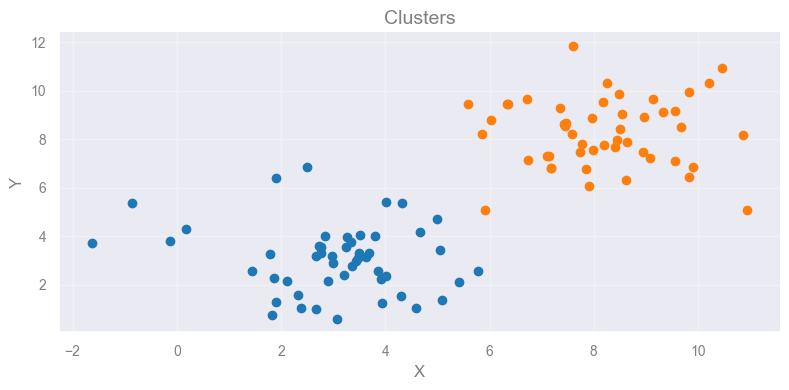

In [2]:
# Set random seed for reproducibility
np.random.seed(2026)

# select number of samples/points per cluster
num_samples = 50

# Generate cluster 1 with normal distribution
cluster1_mean = [3, 3]
cluster1_cov = [[2, 0], [0, 2]]
cluster1_samples = np.random.multivariate_normal(cluster1_mean, 
                                                 cluster1_cov, 
                                                 num_samples)

# Generate cluster 2 with normal distribution
cluster2_mean = [8, 8]
cluster2_cov = [[2, 0], [ 0, 2]]
cluster2_samples = np.random.multivariate_normal(cluster2_mean, cluster2_cov, num_samples)

plt.plot(cluster1_samples[:,0],cluster1_samples[:,1], 
         'o', color='tab:blue', label='Cluster 1')

plt.plot(cluster2_samples[:,0],cluster2_samples[:,1], 
         'o', color='tab:orange', label='Cluster 2')

add_plot_info()    



The above plot is the result of the mock data creation. In reality what we would see is the following plot (i.e. only the data without any idea of the original group).

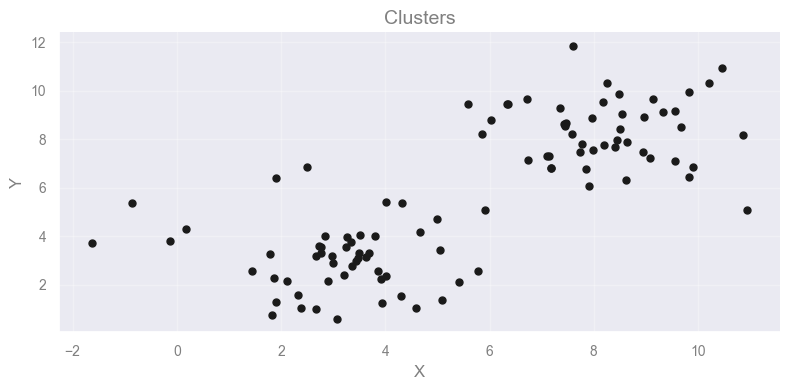

In [3]:
X = np.concatenate((cluster1_samples,cluster2_samples))

plt.plot(X[:,0], X[:,1] , '.k', ms=10) 

add_plot_info()


**Implementation**

Throughout the machine-learning part we will be using the [scikit-learn](https://scikit-learn.org/stable/index.html) module developed on top of `NumPy`, `SciPy`, and `matplotlib`, offering efficient tools on machine-learning applications, data mining, and data analysis. 

We will use [`sklearn.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans), for which the most important (currently) option is the number of groups (we **guess**). A valid option is of course 2.

In [4]:
from sklearn.cluster import KMeans

# number of clusters
Clusters_kmeans = 2

# preparing the model with this number of clusters
kmeans_model = KMeans(n_clusters=Clusters_kmeans)
# fitting the model to the data
kmeans_model.fit( X )

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 2)",

**Check** how we apply the algorithm:

1. Selecting the parameters (e.g. number of clusters)
2. Run the algorithm using the `.fit()` method (model learns from data)

In [5]:
# returning the cluster identified
print("Cluster centers:")
print(kmeans_model.cluster_centers_)

# comparing with the real ones
print()
print("Real centers:")
print(cluster1_mean, cluster2_mean)

Cluster centers:
[[3.08491726 3.10191329]
 [8.21070614 8.33597448]]

Real centers:
[3, 3] [8, 8]


The algorithm returns the class assigned to each data point:

In [6]:
print(kmeans_model.labels_)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


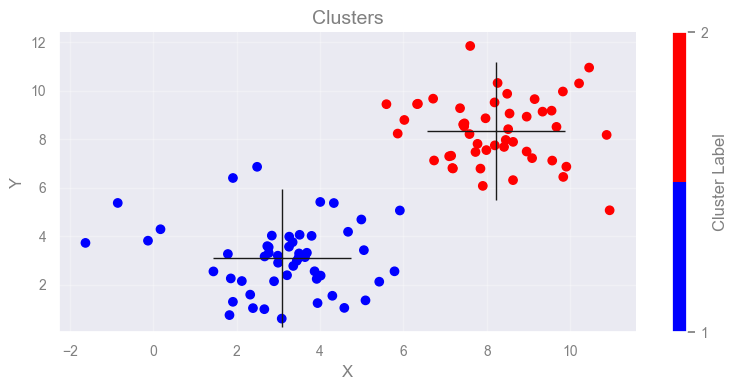

In [7]:
# coordinates of the clusters for plotting
cc_x = kmeans_model.cluster_centers_[:,0]
cc_y = kmeans_model.cluster_centers_[:,1]

# plotting the centers
plt.plot(cc_x, cc_y, 'k+', ms=100)

# plotting the datapoints color-coded according 
# to the cluster they have been assigned to
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat = plt.scatter( X[:,0], X[:,1], c=kmeans_model.labels_, edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

add_plot_info()

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [10 min]**</font>    

**Objective:** Play around with the number of clusters as an input to K-means and explore the effect.

**Task:** Use the following function (cluster_generator) to create some clusters. It does it automatically for you so that *you do not know how many clusters it creates* (well... you can find out but you **shouldn't**!). It returns an array of positions for all samples from all clusters. 

- Plot the samples and guess the number of clusters. 

- Put this into K-means and run the algorithm. 

- Discuss with your partner what you notice. You can run it a few times.

</div>

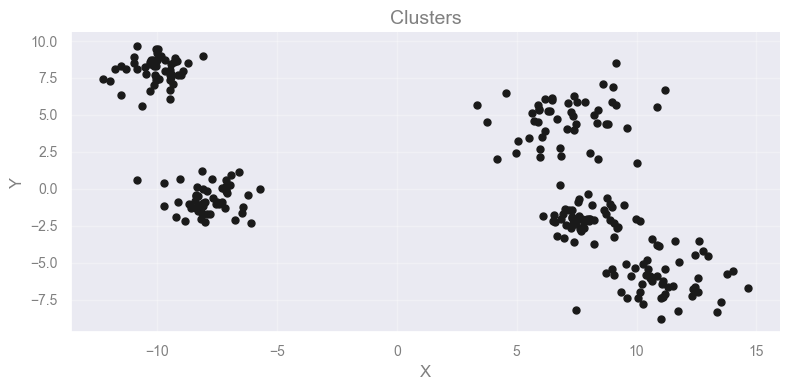

In [8]:
def cluster_generator(num_samples=50, verbose=False, seed=None):
    """ A function to automatically generate random 
    clusters. It returns one single dataset (points 
    with x and y) for all clusters (as a test set 
    for exercise) and the cluster centers. 
    
    num_samples: 50    , numper of points per cluster
    verbose:     False , not printing any information on 
                       the clusters
    seed:        None  , generate random values, else  
                       assign a value for reproducability. 
    """
    # for reproducability
    if seed is not None:
            np.random.seed(seed)
            
    # automatically create a number of clusters in this range
    num_clusters = np.random.randint(3, 7)

    # select number of samples/points per cluster
    num_cluster_samples = num_samples

    # Generate clusters with normal distribution
    center_clusters = []    
    data_clusters = []
    for c in range(num_clusters):        
        cluster_mean = [np.random.randint(-10, 15), np.random.randint(-10, 15)]
#        print(cluster_mean)
        cluster_cov = [[np.random.randint(1,3), 0], [0, np.random.randint(1,3)]]
#        print(cluster_cov)
        cluster_samples = np.random.multivariate_normal(cluster_mean, 
                                                         cluster_cov, 
                                                         num_cluster_samples)
        data_clusters.append(cluster_samples)
        center_clusters.append(cluster_mean)    

        if verbose==True:
            print(cluster_mean)
            plt.scatter(cluster_samples[:,0],cluster_samples[:,1], label=f'Cluster {c}')
            
    
    data_clusters = np.concatenate(data_clusters, axis=0)
#    print(center_clusters)
    return data_clusters, center_clusters


# Generating and visualizing data
X, Xc = cluster_generator()

plt.plot(X[:,0], X[:,1] , '.k', ms=10) 
add_plot_info()

In [ ]:
# Fill in the blanks

from sklearn.cluster import KMeans


# number of clusters -GUESS !
Clusters_kmeans = ...

# preparing the model with this number of clusters
kmeans_model = KMeans(n_clusters=...)
# fitting the model to the data
kmeans_model.fit( ... )

# returning the cluster identified
print(f"Cluster centers from K-means ({len(...)} found):")
print(...)

# comparing with the real ones
print()
print(f"Real centers ({len(Xc)} clusters):")
for c in Xc:
    print(c)
    plt.plot(c[0],c[1], 'x', c='tab:green', ms=80)

# coordinates of the clusters for plotting
cc_x = ...[:,0]
cc_y = ...[:,1]

# plotting the centers
plt.plot(cc_x, cc_y, 'k+', ms=100)

# plotting the datapoints color-coded according 
# to the cluster they have been assigned to
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat = plt.scatter( ..., ..., c=..., edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

plt.text(0.75, 1.05, "x: real", color='g',
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.text(0.84, 1.05, "+: predicted", color='k',
         transform=plt.gca().transAxes,
         verticalalignment='top')


add_plot_info()

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Questions [2 min]**</font>    

How does the algorithm performs with respect to your guess ? <br>How dependant is on the number of clusters?<br>

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The number of clusters defines exactly what K-means will find: you must supply it as a parameter — the algorithm cannot discover it on its own.

If clusters overlap in feature space, K-means still assigns every point to the nearest centroid, often splitting or merging groups that the eye would call distinct.

</details>
</div>

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

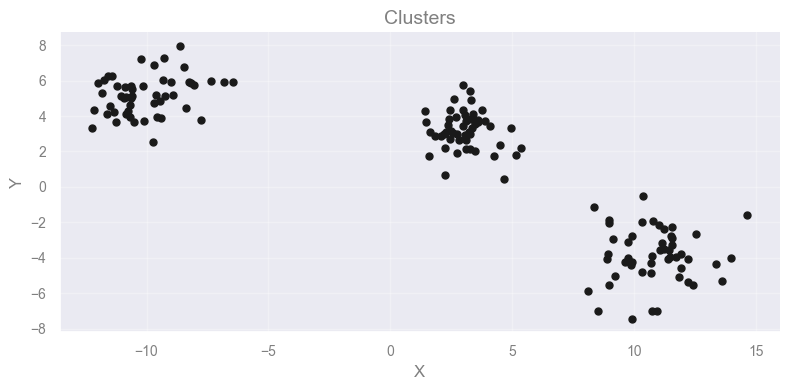

In [9]:
# Generating and visualizing data
X, Xc = cluster_generator(seed=88)

plt.plot(X[:,0], X[:,1] , '.k', ms=10) 
add_plot_info()

Cluster centers from K-means (3 found):
[[ 10.80310614  -3.87195188]
 [-10.02707225   5.18145856]
 [  3.04618638   3.19399703]]

Real centers (3 clusters):
[-10, 5]
[11, -4]
[3, 3]


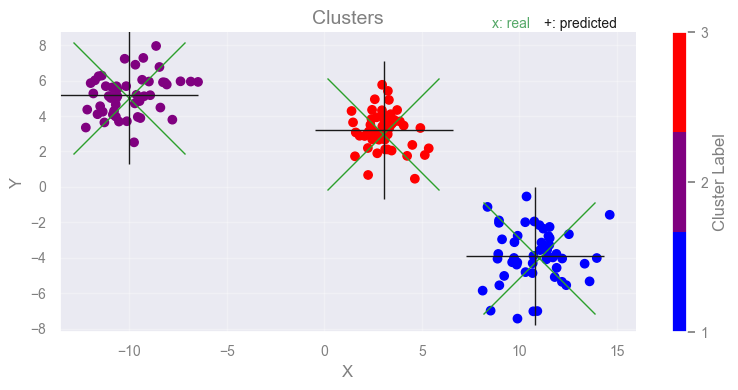

In [10]:
# Running the Kmeans
from sklearn.cluster import KMeans

#### number of clusters -GUESS !
Clusters_kmeans = 3

#### preparing the model with this number of clusters
kmeans_model = KMeans(n_clusters=Clusters_kmeans)
# fitting the model to the data
kmeans_model.fit( X )

# returning the cluster identified
print(f"Cluster centers from K-means ({len(kmeans_model.cluster_centers_)} found):")
print(kmeans_model.cluster_centers_)

# comparing with the real ones
print()
print(f"Real centers ({len(Xc)} clusters):")
for c in Xc:
    print(c)
    plt.plot(c[0],c[1], 'x', c='tab:green', ms=80)

# coordinates of the clusters for plotting
cc_x = kmeans_model.cluster_centers_[:,0]
cc_y = kmeans_model.cluster_centers_[:,1]

# plotting the centers
plt.plot(cc_x, cc_y, 'k+', ms=100)

# plotting the datapoints color-coded according 
# to the cluster they have been assigned to
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat = plt.scatter( X[:,0], X[:,1], c=kmeans_model.labels_, edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

plt.text(0.75, 1.05, "x: real", color='g',
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.text(0.84, 1.05, "+: predicted", color='k',
         transform=plt.gca().transAxes,
         verticalalignment='top')

add_plot_info()

plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

### How to find the best k value? - the "elbow" approach

K-means needs a certain number of clusters to run. Therefore, our selection affects our interpretation (and any potential discoveries!). So, how can we improve (automatically) the selection of clusters that the K-means algorithm will search for?

One answer can be given through the "elbow method". This method is based on the following process:

1. Running the algorithm for a range of different clusters k (from 1 up to a maximum number).

2. Calculating the 'inertia' for each k choice. 

3. Plotting the above quantity as a function of k:

4. Identifying the 'elbow' point in the plot, i.e., the point on the graph where the rate of decrease significantly slows down. This indicates that adding more clusters beyond this point does not substantially reduce inertia, and thus, we do not gain much.

5. The k value corresponding to this point is considered the optimal choice.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">
    
&#9755; This method does not always provide a clear answer, especially if the dataset does not exhibit well-defined clusters or if they have different sizes and densities. 

</div>

_Note: we are using the latest X dataset (from the previous set). You may see different results from others!_

In [11]:
from sklearn import metrics

inert = []
xclusters = range(2,14)
for i in xclusters:
    print(f'-- working with {i} clusters...')
    kmeans_model = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans_model.fit(X)
    inert.append(kmeans_model.inertia_)

-- working with 2 clusters...
-- working with 3 clusters...
-- working with 4 clusters...
-- working with 5 clusters...
-- working with 6 clusters...
-- working with 7 clusters...
-- working with 8 clusters...
-- working with 9 clusters...
-- working with 10 clusters...
-- working with 11 clusters...
-- working with 12 clusters...
-- working with 13 clusters...


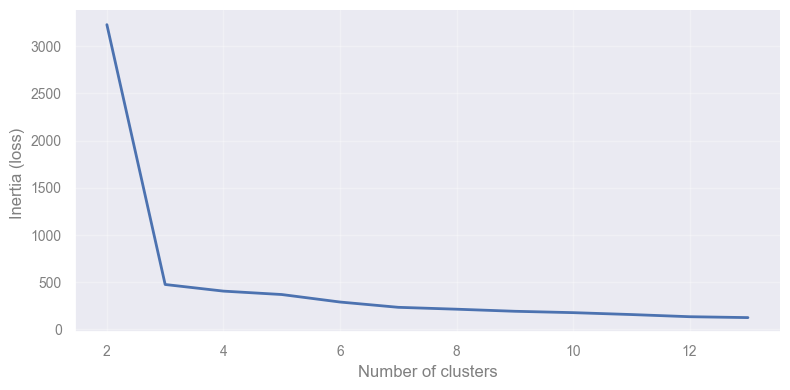

In [12]:
plt.plot( xclusters, inert)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (loss) ')
plt.show()

Let's plug in the number of clusters corresponding to the "elbow" found:

Cluster centers from K-means (3 found):
[[-10.02707225   5.18145856]
 [ 10.80310614  -3.87195188]
 [  3.04618638   3.19399703]]

Real centers (3 clusters):
[-10, 5]
[11, -4]
[3, 3]


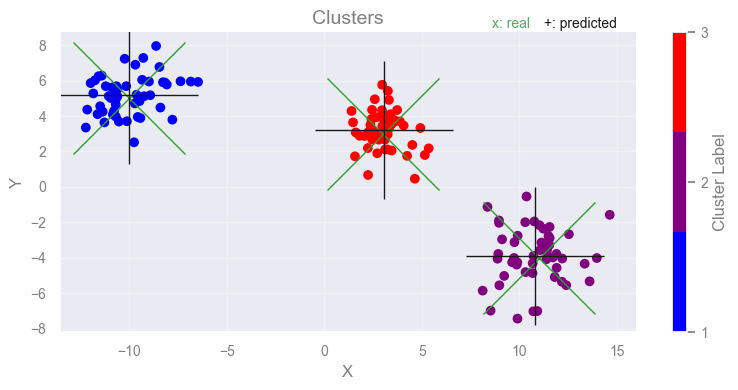

In [13]:
from sklearn.cluster import KMeans


# number of clusters - from "elbow" plot
Clusters_kmeans = 3

# preparing the model with this number of clusters
kmeans_model = KMeans(n_clusters=Clusters_kmeans)
# fitting the model to the data
kmeans_model.fit( X )

# returning the cluster identified
print(f"Cluster centers from K-means ({len(kmeans_model.cluster_centers_)} found):")
print(kmeans_model.cluster_centers_)

# comparing with the real ones
print()
print(f"Real centers ({len(Xc)} clusters):")
for c in Xc:
    print(c)
    plt.plot(c[0],c[1], 'x', c='tab:green', ms=80)

# coordinates of the clusters for plotting
cc_x = kmeans_model.cluster_centers_[:,0]
cc_y = kmeans_model.cluster_centers_[:,1]

# plotting the centers
plt.plot(cc_x, cc_y, 'k+', ms=100)

# plotting the datapoints color-coded according 
# to the cluster they have been assigned to
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat2 = plt.scatter( X[:,0], X[:,1], c=kmeans_model.labels_, edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat2, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

plt.text(0.75, 1.05, "x: real", color='g',
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.text(0.84, 1.05, "+: predicted", color='k',
         transform=plt.gca().transAxes,
         verticalalignment='top')

add_plot_info()

plt.show()

### Other metrics to automate the cluster number

Now, given that we do not know anything apriori for the numbers of clusters, there are some metrics that can used to determine the performance in each case. 

#### Silhouette Score

Using the distances between the points in the same cluster and theirs with all other points in the next nearer cluster:

$$
s = \frac{b - a}{\max(a,b)}
$$
where $a$ corresponds to the mean distance between a sample and all other samples _within the same cluster_, while $b$ is the mean distance of a sample (in the examined cluster) with all other points in the _next nearest cluster_. 

&#10509; A **higher** value indicates better performance (-1...1).

#### Calinski-Harabasz Index

Similar to the silhouette score, but using the ratio of the sum of dispersion of the samples within each cluster and the dispersion of the clusters in total. For a set of data $E$ of size $n_E$ which has been clustered into $k$ clusters, it is defined as:

$$
s = \frac{\mathrm{tr}(B_k)}{\mathrm{tr}(W_k)} \times \frac{n_E-k}{k-1}
$$
where $\mathrm{tr}(B_k)$ is the trace of the between group dispersion matrix, and $\mathrm{tr}(W_k)$ the trace of the within-cluster dispersion matrix, defined as:

$$
W_k = \sum_{q=1}^{K} \sum_{x \in C_q} (x - c_q)(x - c_q)^T
$$
$$
B_k = \sum_{q=1}^{k} n_q(c_q-c_E)(c_q-c_E)^T
$$
with $C_q$ the set of points in cluster $q$, $c_q$ the center of cluster $q$, $c_E$ the center of $E$, and $n_q$ the number of points in cluster $q$.  

&#10509; A **higher** value indicates better performance (denser and well separated clusters). 

#### Davies-Bouldin Index

It is an index that calculates the 'similarity' between clusters, and actually measures how the distance between clusters compares with the sizes of the clusters themselves.  

$$
DB = \frac{1}{k} \sum_{i=1}^{k} \max_{i \neq j} R_{ij}
$$
where $R_{ij} = \frac{s_i+s_j}{d_{ij}}$ corresponds to the similarity measurement, $s_i$ ($s_k$) is the average distance between each point of cluster $i$ (k) and the centroid of that cluster (diameter), and $d_{ij}$ is the distance between cluster centroids $i$ and $j$. The form chosen for $R_{ij}$ is a nonnegative and symmetric. 

&#10509; A **lower** value (closer to 0) indicate better performance.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">
    
&#9755; You can (should!) check [sklearn's clustering metrics page](https://scikit-learn.org/stable/modules/clustering.html) for more details regarding the drawbacks and advantages of each metric.

</div>

Let's see them in action!


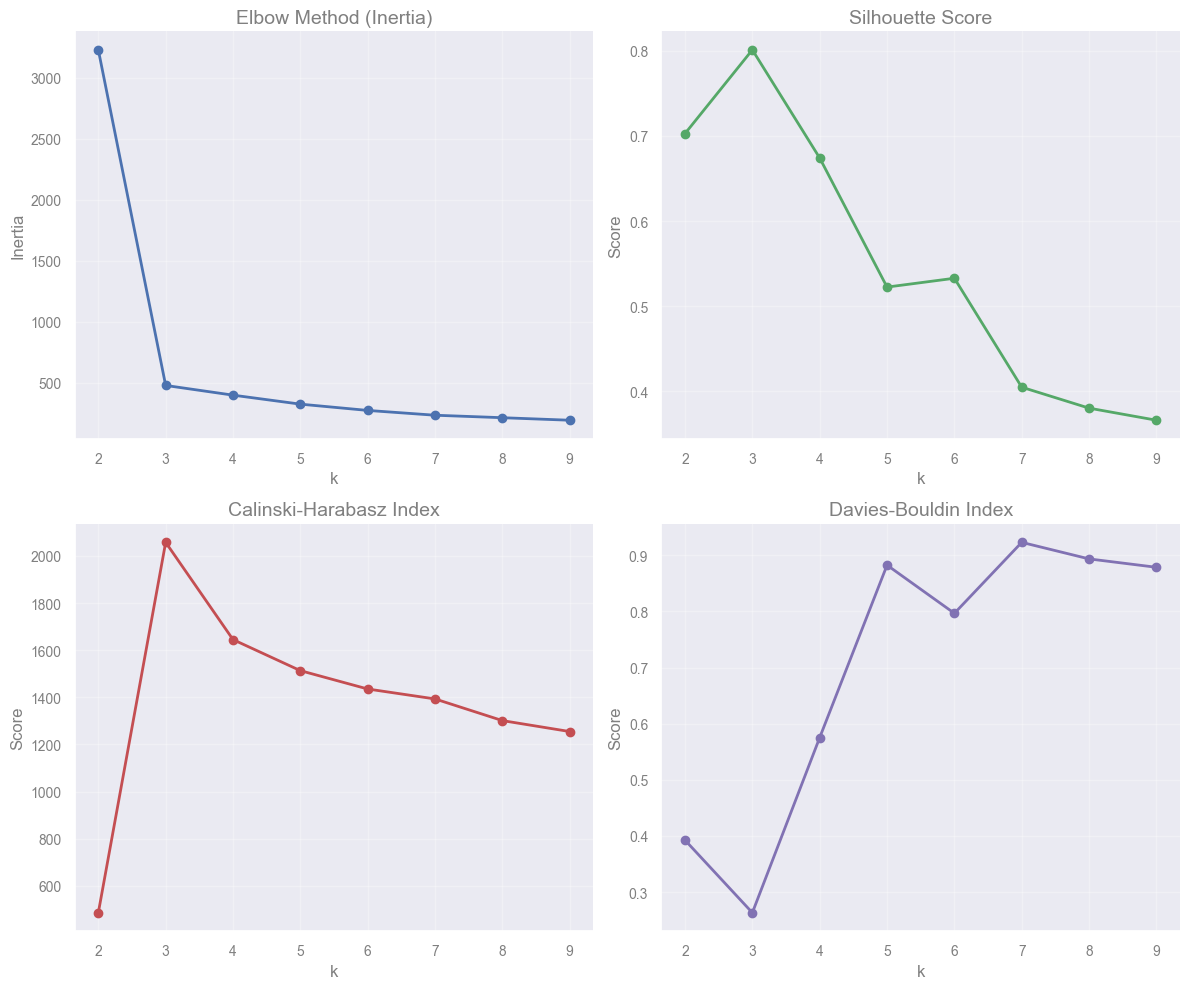

In [14]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Define range of cluster numbers to test
k_values = range(2, 10)

# Initialize lists to store scores
inertia = []
silhouette = []
calinski = []
davies = []

# Fit KMeans and compute metrics for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))
    calinski.append(calinski_harabasz_score(X, labels))
    davies.append(davies_bouldin_score(X, labels))

# Plot all metrics for visual comparison
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(k_values, inertia, 'bo-')
axs[0, 0].set_title('Elbow Method (Inertia)')
axs[0, 0].set_xlabel('k')
axs[0, 0].set_ylabel('Inertia')

axs[0, 1].plot(k_values, silhouette, 'go-')
axs[0, 1].set_title('Silhouette Score')
axs[0, 1].set_xlabel('k')
axs[0, 1].set_ylabel('Score')

axs[1, 0].plot(k_values, calinski, 'ro-')
axs[1, 0].set_title('Calinski-Harabasz Index')
axs[1, 0].set_xlabel('k')
axs[1, 0].set_ylabel('Score')

axs[1, 1].plot(k_values, davies, 'mo-')
axs[1, 1].set_title('Davies-Bouldin Index')
axs[1, 1].set_xlabel('k')
axs[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()


Our pick would be 3 clusters in this case. We note the following:

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

1. In this case all the metrics are consistent - but they could provide **slightly different results**, as they are _sensitive_ to different cluster properties. 
    
2. **Combining** different approaches leads to robust results. 

3. But careful **interpretation** is required to derive non-misleading conclusions. 
    
</div>

## Selecting a tool - the DBSCAN algorithm

The DBSCAN (Density Based Spatial Clustering of Applications with Noise) algorithm views clusters as areas of high density separated by areas of low density. Thus, clusters found by DBSCAN can be of any shape - as opposed to other algorithms (K-means for example) which assume that clusters are convex shaped.

It uses 2 parameters:
* $eps$ : neighborhood size
* $minPts$ : minimum number of points for a neighborhood to be considered dense

With a **sinlge scan** we can label the points as: core, border, noise. How?

-  A point $p$ is defined **core** if at least $minPts$ points are within the area defined by $eps$ (including itself).
-  A **border** point is a non-core point that has at least one core point in its neighborhood
-  A **noise** point is neither a core nor a border point. There represent outliers in the data set


![dbscan.png](images/dbscan.png)

<table><tr><td width=700><center><br>
    Figure 6. Definition of core, border, and noise points, according to DBSCAN,<br>
(Credit: <a href="https://arogozhnikov.github.io/2017/07/10/opera-clustering.html"  target="_blank" rel="noopener noreferrer">Clustering applied to showers in the OPERA, by Alex Rogozhnikov</a>)
<br></center></td></tr></table>

Having defined these points, DBSCAN operates as follows:

**Steps:**

1. The algorithm selects a core point that has not been explored.

2. It finds the points that are within an `eps` distance from this point and examines them.

3. If these points are also core points, it examines their `eps`-neighborhood, expanding the cluster.

4. The above process is applied recursively to all points (core points and border points), further expanding the cluster it is examining until all points it has visited are exhausted.

5. When these points are exhausted, it selects the next unvisited core point (in another cluster) and continues the previous process.

6. The process ends when all points have been assigned to a cluster or identified as noise.


![dbscan-smiley.gif](images/dbscan-smiley.gif)

<table><tr><td width=700><center><br>
    Figure 7. An example of how it constructs clusters (right).<br>
(Credit: <a href="https://arogozhnikov.github.io/2017/07/10/opera-clustering.html"  target="_blank" rel="noopener noreferrer">Clustering applied to showers in the OPERA, by Alex Rogozhnikov</a>)
<br></center></td></tr></table>

**Complexity**

$O(n^2)$, where n is the number of points. 

**Pros**
- Any number of clusters
- Clusters of varying size and shape
- Finds and ignores outliers

**Cons**
- Relatively slow
- Extremely sensitive to parameters choice
- In rare cases, border points move to an other cluster when DBSCAN is re-run
- Serious troubles with clusters with varying density<br>
  *(OPTICS and HDBSCAN are variations which address this problem)*

### Example use of DBSCAN

In the following example we artificially create two groups of data and we use the DBSAN algorithm.

**Creating some data**

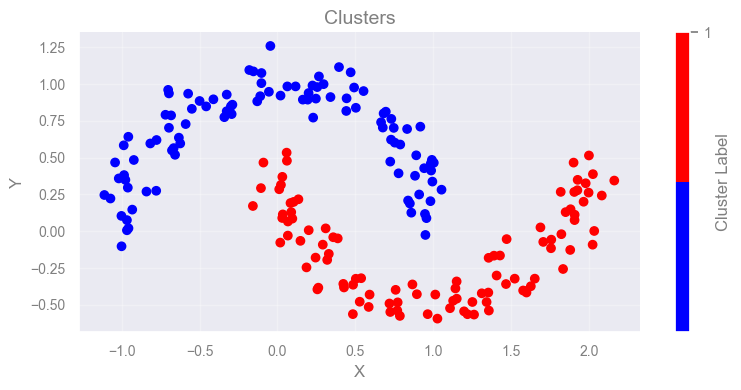

In [15]:
# import this to create some fancy data
from sklearn.datasets import make_moons

# Generate synthetic data (moons dataset)
Xd, y = make_moons(n_samples=200, noise=0.1, random_state=2026)

num_classes = len(set(y))
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=num_classes)
scat2 = plt.scatter( Xd[:,0], Xd[:,1], c=y, 
                    edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat2, ticks=range(1,num_classes+2,1))   # number of clusters
cb.set_ticklabels(range(1,num_classes+2,1))
cb.set_label('Cluster Label')

add_plot_info()    



What we should see if we combine into one dataset.

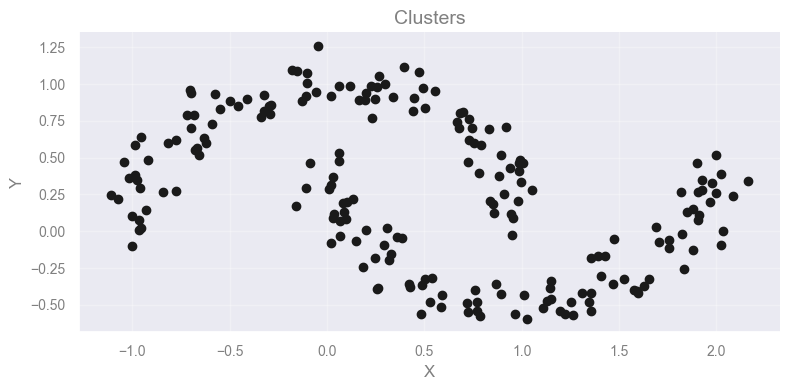

In [16]:
plt.plot(Xd[:,0], Xd[:,1], 'ok') 

add_plot_info()    


**Implementation**

We will use [`sklearn.cluster.DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN). The most important parameters of course are `eps` and `min_samples`.

In [17]:
from sklearn.cluster import DBSCAN

# define the model first
dbscan = DBSCAN(eps=0.08, min_samples=3)
# fit the data
dbscan.fit(Xd)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.08
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](99, 2)","[[ 0.03, 0.11], [-0.3 , 0.85], [ 1.98, 0.33], ..., [ 1.76,-0.06], [ 0.68, 0.8 ], [ 0.54,-0.32]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](99,)","[ 0, 3, 6,...,196,197,198]"


**Notice** how all algorithms are applied using the same methods.

Let's see the number of classes returned by the algorithm:

In [18]:
print(set(dbscan.labels_))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(-1)}


Let's visualize the predictions now.


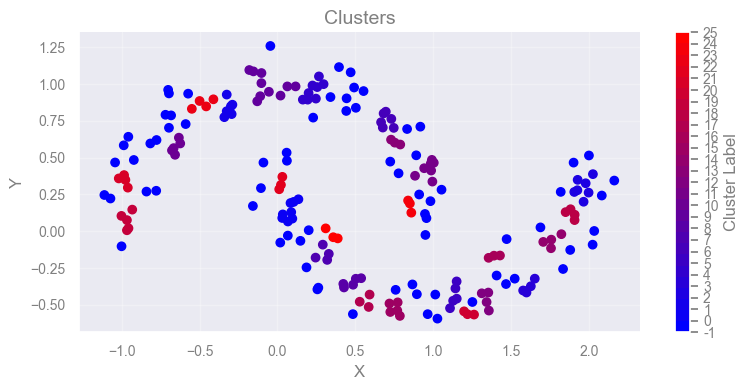

In [19]:
num_classes = len(set(dbscan.labels_))
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=num_classes)
scat2 = plt.scatter( Xd[:,0], Xd[:,1], c=dbscan.labels_, 
                    edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat2, ticks=range(-1,num_classes,1))   # number of clusters excluding noise
cb.set_ticklabels(range(-1,num_classes,1))
cb.set_label('Cluster Label')

add_plot_info()    

Well...this is kind of embarrassing ! DBSCAN should work, what's the problem? 

The 3 panels below show what happens geometrically when `eps` is far from the right value.

Each run uses the same dataset (`Xd`) with `min_samples = 5`. Grey crosses mark points classified as **noise** (label = −1).

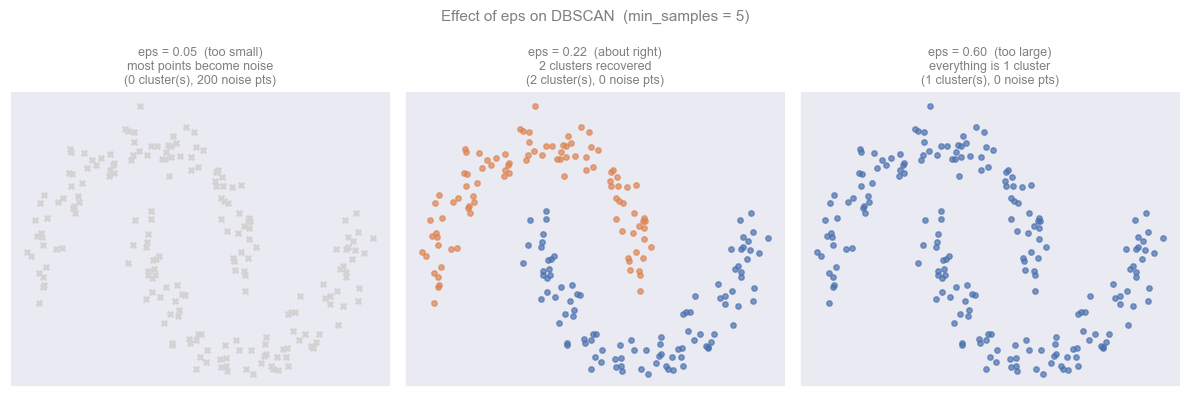

In [20]:
# eps sensitivity demo: same data, 3 different eps values
from sklearn.cluster import DBSCAN

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

eps_values = [0.05, 0.22, 0.60]
subtitles  = [
    'eps = 0.05  (too small)\nmost points become noise',
    'eps = 0.22  (about right)\n2 clusters recovered',
    'eps = 0.60  (too large)\neverything is 1 cluster'
]

for ax, eps_val, subtitle in zip(axes, eps_values, subtitles):
    db     = DBSCAN(eps=eps_val, min_samples=5).fit(Xd)
    labels = db.labels_

    # noise points in grey
    noise = labels == -1
    ax.scatter(Xd[noise, 0], Xd[noise, 1],
               c='lightgrey', s=15, marker='x', zorder=1)

    # one colour per cluster
    for k in sorted(set(labels)):
        if k == -1:
            continue
        mask = labels == k
        ax.scatter(Xd[mask, 0], Xd[mask, 1], s=15, alpha=0.7, zorder=2)

    n_cl = len(set(labels) - {-1})
    n_no = int(noise.sum())
    ax.set_title(f'{subtitle}\n({n_cl} cluster(s), {n_no} noise pts)', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Effect of eps on DBSCAN  (min_samples = 5)', fontsize=11)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question [5 min]**</font>    
    
Which are the optimal parameters?<br>    
In order to identify the two clusters play around with the `eps` and `mins_sample`. 

_HINT: suggested ranges 0.05 -- 0.30, 2 -- 7, respectively_

_NOTE: the group of points with -1 indicate noise._<br>

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

A working pair of parameters for this dataset:

- `eps = 0.22`
- `min_samples = 5`

</details>
</div>

## Can we automated the search? 

The previous exercise demonstrated that it's not easy, and perhaps not even obvious, what the optimal parameters are. Indeed, there is a variety of approaches (see for example these articles [statexchange/88872](https://stats.stackexchange.com/questions/88872/a-routine-to-choose-eps-and-minpts-for-dbscan), [stackoverflow/15050389](https://stackoverflow.com/questions/15050389/estimating-choosing-optimal-hyperparameters-for-dbscan)). We need to properly define two parameters.

 - We can identify a similar "elbow" point, by investigating the (sorted) distances for all pointe as a function of the number of points. That can help estimate the `eps` parameter.

 - Regarding the `minPts` we need to apply domain knowledge (i.e. information from the specific problem). However, a general rule is: 2 times the number of dimensions minus 1 ([Sander et al., 1998](https://link.springer.com/article/10.1023/A:1009745219419)).

Given that second choice, the determination of `eps` becomes a bit easier: once minPts is fixed, we can explore different values for eps. Still, we need a metric that can quantify the performance of the algorithm. We can apply the metrics we used previously but we need to udnerstand the their limitations There are several available (see, for example, [sklearn - clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics)). 

So, let's see how can we search for the optimal `eps`. What we are going to do it to search for a range of `eps` values and make a plot of the number of identified clusters per value. We will then visualize some indicative `eps` values to check the best results. For the optimal number of `minPts` we will follow the rule above, which, given the 2 dimensions of our problem (x,y), results in `minPts` $= 2 \times 2 -1 = 3 $.

0.001 : 1
0.011 : 1
0.020999999999999998 : 2
0.030999999999999996 : 3
0.040999999999999995 : 8
0.05099999999999999 : 16
0.06099999999999999 : 21
0.071 : 25
0.08099999999999999 : 27
0.09099999999999998 : 28
0.10099999999999998 : 21
0.11099999999999999 : 17
0.12099999999999998 : 16
0.13099999999999998 : 10
0.141 : 8
0.15099999999999997 : 7
0.16099999999999998 : 7
0.17099999999999999 : 5
0.18099999999999997 : 5
0.19099999999999998 : 4
0.20099999999999996 : 2
0.21099999999999997 : 2
0.22099999999999997 : 2
0.23099999999999996 : 2
0.24099999999999996 : 2
0.25099999999999995 : 2
0.26099999999999995 : 2
0.27099999999999996 : 2
0.28099999999999997 : 2
0.291 : 2
0.30099999999999993 : 1
0.31099999999999994 : 1
0.32099999999999995 : 1
0.33099999999999996 : 1
0.34099999999999997 : 1
0.3509999999999999 : 1
0.36099999999999993 : 1
0.37099999999999994 : 1
0.38099999999999995 : 1
0.39099999999999996 : 1
0.4009999999999999 : 1
0.4109999999999999 : 1
0.42099999999999993 : 1
0.43099999999999994 : 1
0.440

Text(0, 0.5, 'number of clusters')

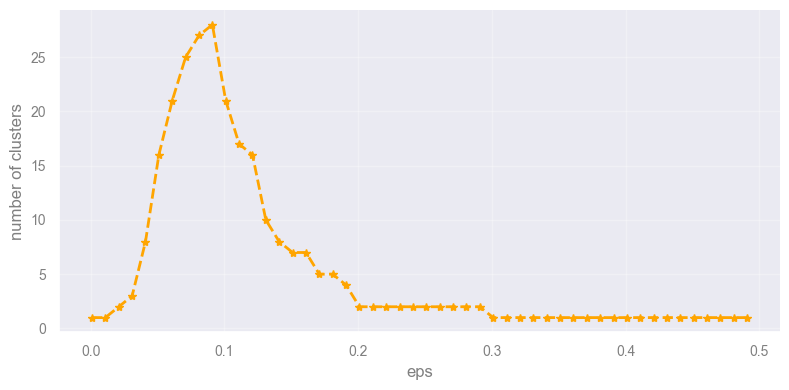

In [21]:
# number of clusters / groups
n_clusters = []
# search range for eps
eps_range = np.arange(0.001, 0.5, 0.01)

# run DBSCAN for each value, and get the number of clusters
for e in eps_range:
    dbscan = DBSCAN(eps=e, min_samples=3)
    dbscan.fit(Xd)
    clstrs = len(set(dbscan.labels_))
    print(e, ":", clstrs)
    n_clusters.append(clstrs)
    
# plotting the results    
plt.plot(eps_range, n_clusters, '*--', c='orange' ) 
plt.xlabel('eps')
plt.ylabel('number of clusters')

Let's try some of these values to visualize the results. We will use the following helpful plotting function. 

In [22]:
def run_n_show(eps_run, ax):
    """A quick funtion to run the DBSCAN with a specific
    eps value, and visualize the result to check.
    ax refers to the subplot id for the plot. """

    # run the algorithm
    dbscan_run = DBSCAN(eps=eps_run, min_samples=3)
    dbscan_run.fit(Xd)

    # visualize the predictions
    num_classes = len(set(dbscan_run.labels_))
    new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=num_classes)
    ax.scatter( Xd[:,0], Xd[:,1], c=dbscan_run.labels_, 
                        edgecolors='face', cmap=new_map)
    ax.set_title(f"run for eps={eps_run}")

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [5 min]**</font>    

**Objective:** Play around with the values of `eps` to find the optimal value.

**Task:** You just need to input various selected values from the plot above and check visually which one seems to work best.

<br>    

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

K-means does find 2 clusters, but they are geometrically wrong.

K-means assumes clusters are roughly spherical (isotropic), so it divides the crescent-shaped moons along a straight boundary rather than following their curved geometry.

DBSCAN has no such assumption: it groups points by local density regardless of shape, which is why it succeeds where K-means fails on this dataset.

</details>
</div>

In [ ]:
fig, ( (ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, 
                            sharey=True, sharex=True,
                            figsize=(10,10))


run_n_show(..., ax1)
ax1.set_ylabel('Y')

run_n_show(..., ax2)
ax2.set_xlabel('X')

run_n_show(..., ax3)
ax3.set_ylabel('Y')

run_n_show(..., ax4)
ax4.set_xlabel('X')

plt.tight_layout()
plt.show()

plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

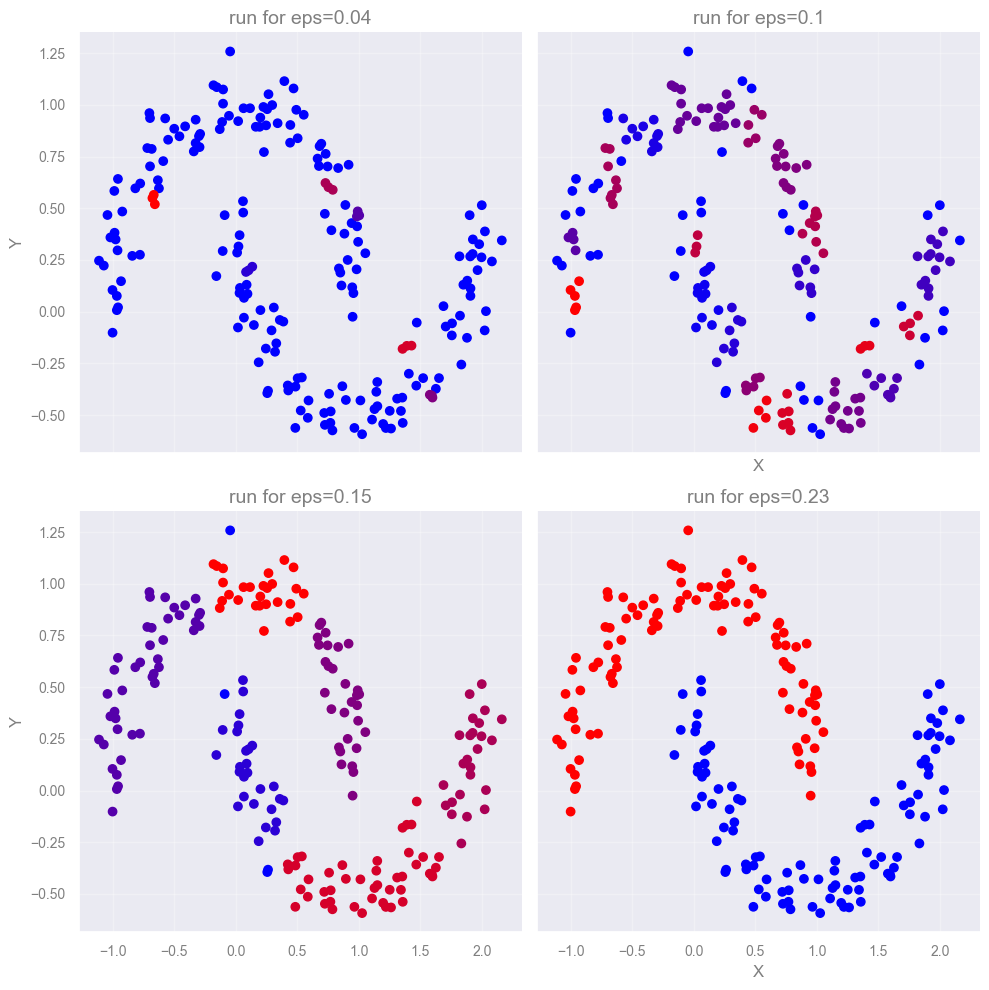

In [23]:
fig, ( (ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, 
                            sharey=True, sharex=True,
                            figsize=(10,10))

run_n_show(0.04, ax1)
ax1.set_ylabel('Y')

run_n_show(0.1, ax2)
ax2.set_xlabel('X')

run_n_show(0.15, ax3)
ax3.set_ylabel('Y')

run_n_show(0.23, ax4)
ax4.set_xlabel('X')

plt.tight_layout()
plt.show()

plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

## Comparing the two algorithms

Let's now check if K-means is able to recover the clusters. It is kind of obvious what should be the number of clusters... 

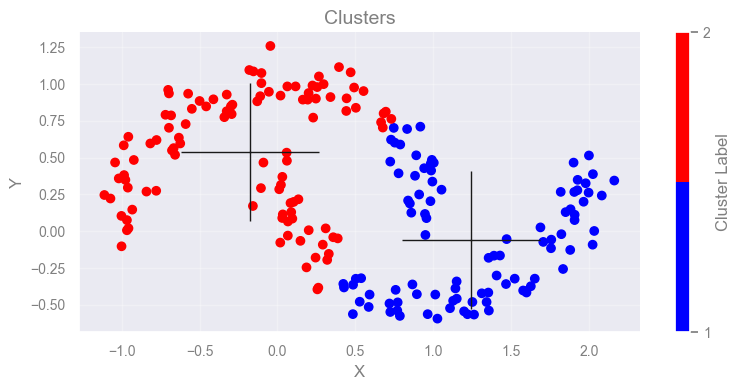

In [24]:
# number of clusters
Clusters_kmeans = 2

# preparing the model with this number of clusters
kmeans_model = KMeans(n_clusters=Clusters_kmeans)
# fitting the model to the data
kmeans_model.fit( Xd )

# coordinates of the clusters for plotting
cc_x = kmeans_model.cluster_centers_[:,0]
cc_y = kmeans_model.cluster_centers_[:,1]

# plotting the centers
plt.plot(cc_x, cc_y, 'k+', ms=100)

# plotting the datapoints color-coded according 
# to the cluster they have been assigned to
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat2 = plt.scatter( Xd[:,0], Xd[:,1], c=kmeans_model.labels_, edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat2, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

add_plot_info()

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question [2 min]**</font>    
    
What would you comment regarding the performance of K-means instead of DBSCAN?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

`eps` values near the peak of the cluster-count curve produce too many fragmented clusters.

Values below the peak cause DBSCAN to label most points as noise.

Values slightly above the peak give clean separation into 2 clusters.

Increasing `eps` further merges all points into a single cluster.

</details>
</div>

# Application

The following dataset originates from measurements of two spectral lines for a sample of stars. The strength of a spectral line can be measured by its equivalent width (EQW).  

![equivalent_width-wiki.jpg](images/equivalent_width-wiki.jpg)
<table><tr><td width=700><center><br>
    Figure 8. Defining EQW: the width of a line with intensity equal to the local continuum and total flux equal to that of the line.   <br>
(Credit: <a href="https://en.wikipedia.org/wiki/Equivalent_width" 
 target="_blank" rel="noopener noreferrer">Wikipedia: Equivalent Width, by Szdori </a>)
<br></center></td></tr></table>

Therefore, the larger the EQW the stronger the line is. The presence of spectral lines depends on the temperature of the stellar sources. Because of this, we see a developmet of different spectral lines as we move from the hottest to the cooler stars. This corresponds to moving from earlier spectral types (O-type stars; 50-25kK) to later ones (M-type; 3.5-2.5kK) [see the Morgan-Keenan spectral classification scheme](https://en.wikipedia.org/wiki/Stellar_classification)].

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [15 min]**</font>    

**Objective:** Identify the clusters of spectral types for hot massive stars based on the ratio of spectral lines.

**Taks:** To do this follow the automated approach for K-means. In particular:
    
- Run the automated estimate of the identified clusters we run previously for K-means.

- Check all metrics and decide which one to use. 
    
- Run the K-means algorithm with the selected number of clusters and visualize the result.
    
- Think over your results (what could they mean?) and cross-check with the real data. 

</div>

In [25]:
def flospecConv(arg):
    """
    Function to convert from spectral types to 
    float numbers (e.g. B0,O9.5 to 20.0,19.5)
    and backwards.
    """ 
    try:
        float(arg)
        if str(arg)[0]=='1':
            sp = 'O'
        elif str(arg)[0]=='2':
            sp = 'B'
        elif str(arg)[0]=='3':
            sp = 'A'
        else:
            sys.exit(' ! ERROR: more than O/B stars! Adjust conversion function.')
        new_arg = sp+str(arg)[1:]
    except ValueError:
        if arg[0]=='O' or arg[0]=='o':
            fl = '1'
        elif arg[0]=='B' or arg[0]=='b':
            fl = '2'
        elif arg[0]=='A' or arg[0]=='a':
            fl = '3'
        else:
            sys.exit(' ! ERROR: Check input! If more than O/B stars adjust conversion function.')
        new_arg = float(arg.replace(arg[0],fl))

    return new_arg


In [26]:
# Reading the data file and selecting lines
# when selecting lines do it in pairs, and with shorter line first

PATH_data = "data/stellar_types.dat"

sellines = ['HeII/4200', 'HeI/4471'] # in order of wavelength
#sellines = ['HeI/4471', 'MgII/4481'] # in order of wavelength

stars=defaultdict(list)
with open(PATH_data,'r') as inf:
    for line in inf:
        cols = line.split()
        objt = cols[0]
        spln = cols[1]
        if spln in sellines: 
#            print(splin)
            eqw = cols[2]
            stars[objt].append(eqw)             # the shorter line is appended first!
            
#print(stars)

# Creating data structures:

sptype, flosptype, eqwA, eqwB = [], [], [], []
for s in stars.keys():
    sptype.append(s.split('-')[0])
    flosptype.append(flospecConv(s.split('-')[0]))
    eqwA.append(float(stars[s][0]))                 # A is the shorter line
    eqwB.append(float(stars[s][1]))                 # B is the other line (obviously!)
    
# > Organizing data in an analysis-ready fashion:
X = np.column_stack((eqwA,eqwB))

print('Sample shape:')
print("___________________________________")
print('  X  | ' + str(X.shape))
print('     | ' + str(X.shape[0]) + ' samples x ' + str(X.shape[1]) + ' diagnostics' )

Sample shape:
___________________________________
  X  | (697, 2)
     | 697 samples x 2 diagnostics


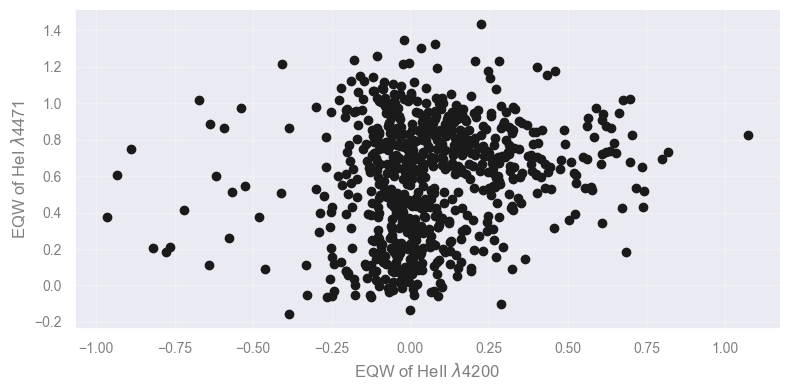

In [27]:
# Visualize data

scat = plt.scatter(eqwA, eqwB, c='k')

# automatic labelling from the lines 
plt.xlabel(r""+f"EQW of { sellines[0].split('/')[0]} $\lambda${sellines[0].split('/')[1]}")
plt.ylabel(r""+f"EQW of { sellines[1].split('/')[0]} $\lambda${sellines[1].split('/')[1]}")

# simpler approach
# plt.xlabel(r"EQW of line HeII $\lambda$4200 ")
# plt.ylabel(r"EQW of line HeI $\lambda$4471 ")

plt.show()

In [28]:
# Enter code here (automated detection 
# of clusters for K-means)

In [29]:
# Enter code here (application of K-means with 
# selected number of clusters and visualization)

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

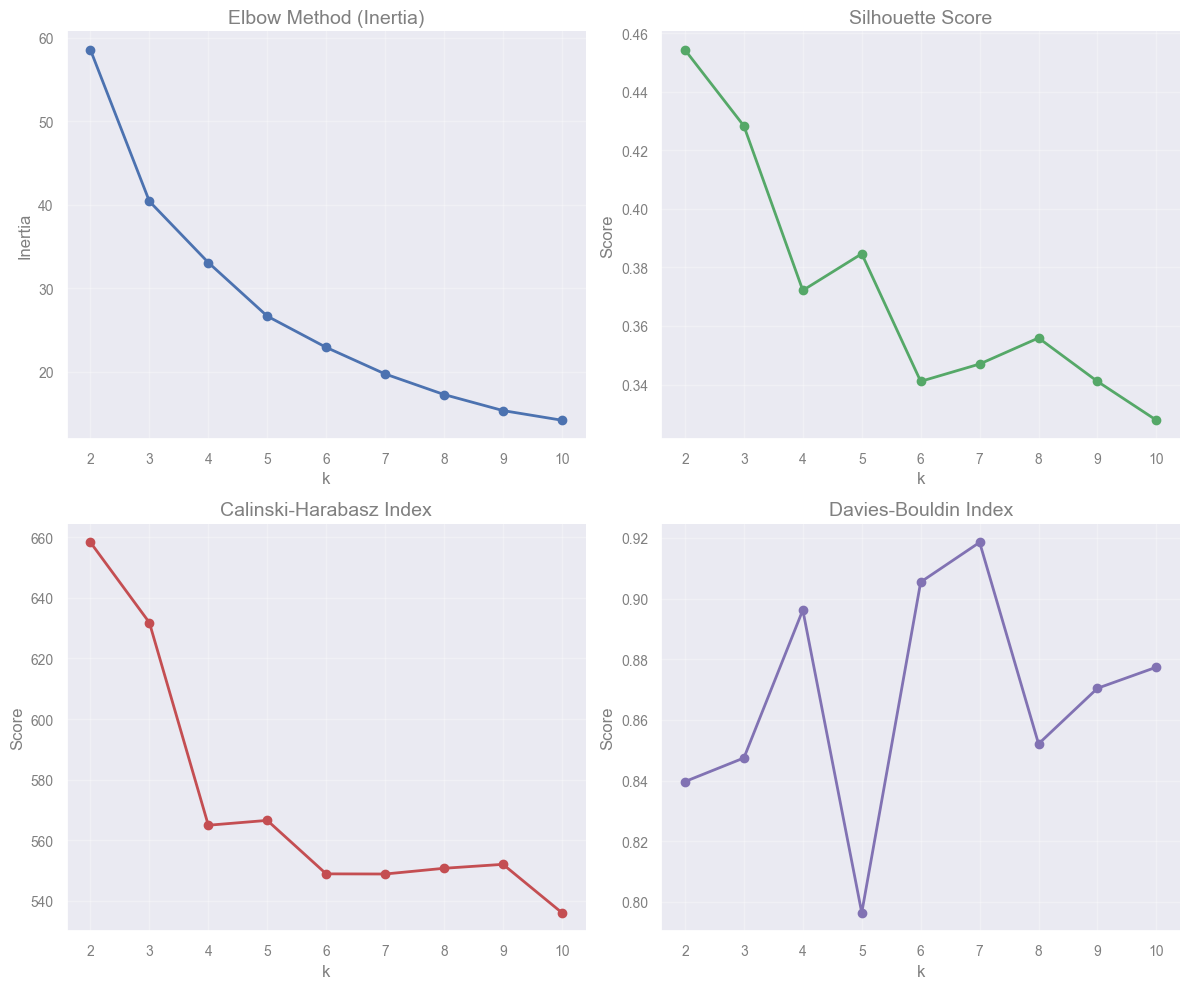

In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Define range of cluster numbers to test
k_values = range(2, 11)

# Initialize lists to store scores
inertia = []
silhouette = []
calinski = []
davies = []

# Fit KMeans and compute metrics for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))
    calinski.append(calinski_harabasz_score(X, labels))
    davies.append(davies_bouldin_score(X, labels))

# Plot all metrics for visual comparison
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].plot(k_values, inertia, 'bo-')
axs[0, 0].set_title('Elbow Method (Inertia)')
axs[0, 0].set_xlabel('k')
axs[0, 0].set_ylabel('Inertia')

axs[0, 1].plot(k_values, silhouette, 'go-')
axs[0, 1].set_title('Silhouette Score')
axs[0, 1].set_xlabel('k')
axs[0, 1].set_ylabel('Score')

axs[1, 0].plot(k_values, calinski, 'ro-')
axs[1, 0].set_title('Calinski-Harabasz Index')
axs[1, 0].set_xlabel('k')
axs[1, 0].set_ylabel('Score')

axs[1, 1].plot(k_values, davies, 'mo-')
axs[1, 1].set_title('Davies-Bouldin Index')
axs[1, 1].set_xlabel('k')
axs[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()


Cluster centers from K-means (5 found):
[[-0.66236952  0.49937697]
 [ 0.0205388   0.92204375]
 [-0.01056778  0.15670858]
 [ 0.42132856  0.6945392 ]
 [-0.01201803  0.55630588]]


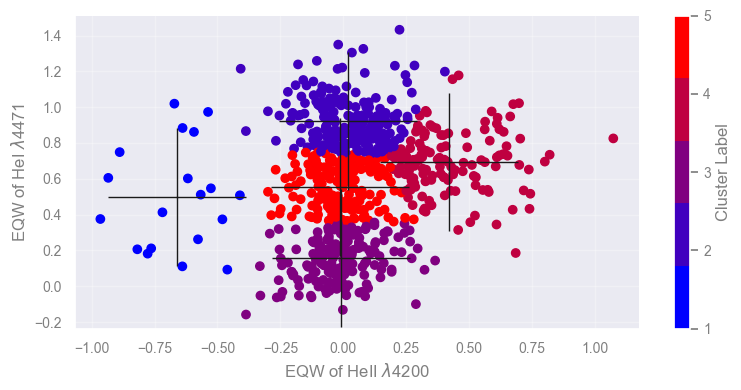

In [31]:
# Select number of clusters
Clusters_kmeans = 5

# Run the algorithm
kmeans_model = KMeans(n_clusters=Clusters_kmeans)
kmeans_model.fit( X )

# Return identified clusters
print(f"Cluster centers from K-means ({len(kmeans_model.cluster_centers_)} found):")
print(kmeans_model.cluster_centers_)

# Plotting the clusters' centers
cc_x = kmeans_model.cluster_centers_[:,0]
cc_y = kmeans_model.cluster_centers_[:,1]
plt.plot(cc_x, cc_y, 'k+', ms=100)

# Visualization of data and clusters
new_map = matplotlib.cm.gray.from_list('clustering', ('blue', 'red'), N=Clusters_kmeans)
scat2 = plt.scatter( X[:,0], X[:,1], c=kmeans_model.labels_, edgecolors='face', cmap=new_map)
cb = plt.colorbar(scat2, ticks=range(0,Clusters_kmeans+1,1))   # number of clusters
cb.set_ticklabels(range(1,Clusters_kmeans+2,1))
cb.set_label('Cluster Label')

plt.xlabel(r""+f"EQW of { sellines[0].split('/')[0]} $\lambda${sellines[0].split('/')[1]}")
plt.ylabel(r""+f"EQW of { sellines[1].split('/')[0]} $\lambda${sellines[1].split('/')[1]}")

plt.grid(True)

plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question [3 min]**</font>    

Take a few minutes and think over the results - what could possibly these clusters mean?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

Run the cell below to overlay the spectral types on the plot.

- The bulk of sources has HeII 4200 ≈ 0 Å — mid- to late-B stars where HeII absorption is absent.
- Sources with positive HeII 4200 are late-O and early-B stars, where HeII is still ionised.
- Along the HeII 4200 = 0 Å axis, HeI 4471 increases from 0 Å to ~0.6 Å and beyond, tracing the temperature decline from late-O/early-B to mid- and late-B stars.
- A cluster left of HeII 4200 = 0 Å shows negative equivalent widths, most likely emission rather than absorption — erroneous measurements or genuine O-type emission stars.

</details>
</div>

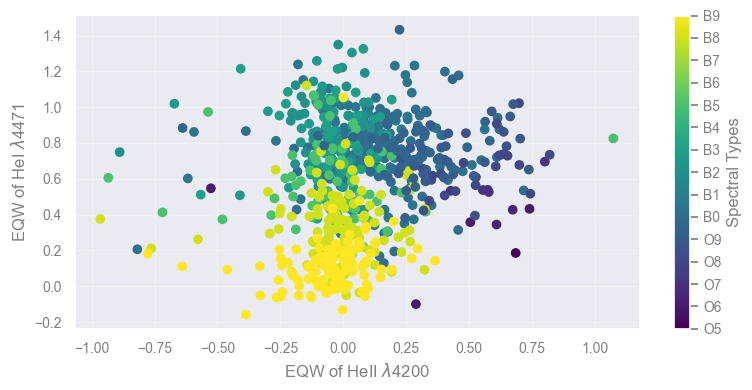

In [32]:
# Plotting the real data

fig = plt.figure()
scat = plt.scatter(eqwA, eqwB, c=flosptype, edgecolors='face', cmap="viridis")

# Plot all spectral types
specrange = np.arange(15,30,1)
cb = plt.colorbar(scat, ticks=specrange)   # range of available spectral types
cb.set_ticklabels([flospecConv(a) for a in specrange])
# or if you want to present a smaller or indicative number of types
# cb = plt.colorbar(scat, ticks=[15,22,29])   # range of available spectral types
# cb.set_ticklabels(['O5','B2','B9'])
cb.set_label('Spectral Types')

plt.xlabel(r""+f"EQW of { sellines[0].split('/')[0]} $\lambda${sellines[0].split('/')[1]}")
plt.ylabel(r""+f"EQW of { sellines[1].split('/')[0]} $\lambda${sellines[1].split('/')[1]}")

plt.show()

# Clustering algorithms overview

But how a good clustering workflow hould look like?

To takle effectively a clustering problem initialy you can follow thise steps: 

1. Load your data
2. Visualize your data, different stuctures requier different algorithms
3. Choose the algorithm you want and fit it
4. Visualize the results and see if it is acceptable

Here we present a set of [**sklearn clustering**](http://scikit-learn.org/stable/modules/clustering.html) algorithms with toy datasets, and then we continue by applying some of them in various astrophyiscal datasets.

This serves as a showcase of the available methods and how they compare. You can easily adapt any of these methods to the following examples or your own problems.

![sklearn_clustering.png](images/sklearn_clustering.png)

<table><tr><td width=700><center><br>
    Figure 9. A comparison of the clustering algorithms in scikit-learn.<br>
(Credit: <a href="https://scikit-learn.org/stable/modules/clustering.html"  target="_blank" rel="noopener noreferrer">Overview of clustering methods, scikit-learn API</a>)
<br></center></td></tr></table>


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Question [2 min]**</font>        

Explore the results above - what differences do you notice?

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

- There is no single best algorithm.
- Not all algorithms identify the same number of clusters.
- Some algorithms detect arbitrary cluster shapes better than others.
- Some algorithms are faster.
- Intuitive clustering may not apply to very high-dimensional data.

</details>
</div>

In [33]:
###EOF